# 4. Implementing Matrix Factorization


### (a) Image Reconstruction

## **Objective 1**  
Reconstruct an image with missing pixel values using **Gradient Descent**. Perform the following two cases:  
1. A rectangular block of size 30×30 is missing.  
2. A random subset of 900 (30×30) pixels is missing.  

Tasks:  
- Select an appropriate rank `r`.  
- Run Gradient Descent until convergence.  
- Plot:  
  - The selected missing regions,  
  - The original image,  
  - The reconstructed image.  
- Compute:  
  - **RMSE** (predicted vs ground truth),  
  - **Peak SNR**.  


Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import torchvision

Device Set Up

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda:0")
elif torch.backends.mps.is_available():  # For Mac GPUs
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Working on device:", device)

Working on device: cpu


Setting the Random Seed

Setting a random seed ensures reproducibility by making all random operations—like matrix initialization and pixel masking—produce the same results every time. This allows consistent, verifiable experiments

In [3]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

Loading the Image

Colored image shape (C,H,W): torch.Size([3, 337, 600])
Min pixel value: 0.0
Max pixel value: 1.0


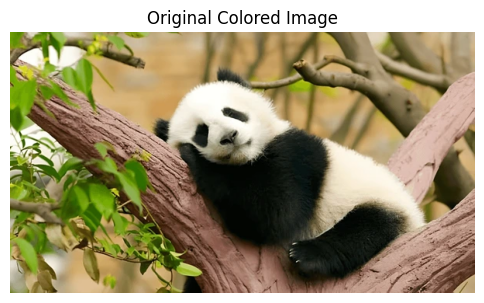

In [4]:
def normalize_image(image_tensor):
    return image_tensor.float() / 255.0


color_img = torchvision.io.read_image(r'C:\Users\Parth Dembla\Downloads\Machine Learning\ES---335-ML-Assignment-2\Task 4\panda.jpg')  # shape: [C, H, W]
color_img = normalize_image(color_img)
print("Colored image shape (C,H,W):", color_img.shape)
print("Min pixel value:", color_img.min().item())
print("Max pixel value:", color_img.max().item())

# Display colored image
plt.figure(figsize=(6,6))
plt.imshow(color_img.permute(1,2,0))  # convert [C,H,W] -> [H,W,C] for matplotlib
plt.title("Original Colored Image")
plt.axis('off')
plt.show()

Converting to Grayscale

Grayscale image shape: torch.Size([337, 600])


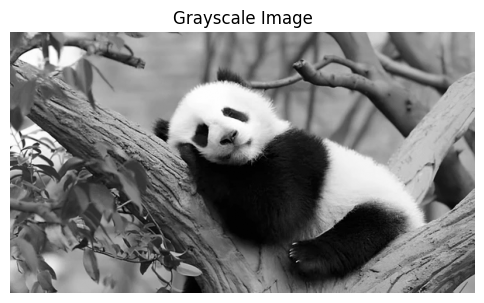

In [5]:
gray_img = color_img.mean(dim=0)  # average over channel dimension -> [H,W]
print("Grayscale image shape:", gray_img.shape)

plt.figure(figsize=(6,6))
plt.imshow(gray_img, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()

# Convert to torch tensor for reconstruction
X = gray_img.clone()  # [H,W] tensor now it is ready for operations like matrix factorization

Move the Image tensor to device using .to(device) argument

In [6]:
X = X.to(device)

Defining Low Rank Reconstruction Function (Matrix Factorization)

In [12]:
def low_rank_reconstruction(X, mask, rank, lr, num_iters):
    """Function which does matrix factorization ; the arguments are:

    X = image tensor of the grayscale image [H,W]; it contains known pixel values
    mask = A tensor [H, W] with 1 for known pixels and 0 for missing pixels. This ensures we only calculate the loss on known pixels.
    r = The low-rank r of the factorization. X ≈ W @ H. Choosing r smaller than min(H, W) enforces a low-rank constraint that helps fill missing pixels using redundancy in the image.
    lr Learning rate for gradient descent. Controls how big each step is when updating W and H.
    Number of Iterations
    """
    
    m, n = X.shape
    W = torch.randn(m, rank, device=device, requires_grad=True)
    H = torch.randn(rank, n, device=device, requires_grad=True)
    
    optimizer = optim.Adam([W, H], lr=lr)
    losses = []
    
    print("--- Starting Gradient Descent ---")
    for it in range(num_iters):
        optimizer.zero_grad()
        X_hat = torch.mm(W, H)
        loss = ((X_hat - X) * mask).pow(2).sum()
        loss.backward()
        optimizer.step()
        
        # Store loss at each iteration
        losses.append(loss.item())
        
        # --- ADDED THIS BLOCK AS REQUESTED ---
        if it % 500 == 0 or it == num_iters-1:
            print(f"GD Iteration {it:5d}, Loss={loss.item():.6f}")
            
    print("--- Gradient Descent Finished ---\n")
    return torch.mm(W, H).detach(), losses

Metrics Calculation Function

In [8]:
def compute_metrics(X_true, X_pred):
    """Compute RMSE and PSNR over the entire image"""
    mse = ((X_true - X_pred).pow(2)).mean()
    rmse = torch.sqrt(mse).item()
    psnr = 20 * torch.log10(1.0 / torch.sqrt(mse)).item()
    return rmse, psnr

**case(i)**: Reconstructing the image for a rectangular block of 30X30 is assumed missing from the image.

Here, a mask is created to simulate missing pixels in the image. torch.ones_like(X) makes a mask of all ones (meaning all pixels are initially known). Then, a 30×30 block starting at (50,50) is set to zeros, marking those pixels as missing. Finally, multiplying X * block_mask sets the pixel values in that block to zero (hidden), while keeping the rest unchanged. This way, the algorithm knows which pixels are observed (1) and which are missing (0).

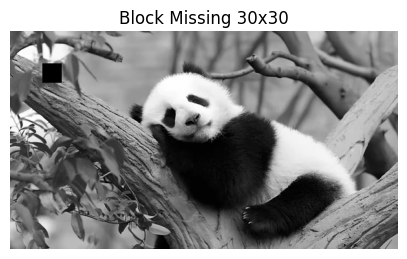

--- Starting Gradient Descent ---
GD Iteration     0, Loss=11991633.000000
GD Iteration   500, Loss=6885.344727
GD Iteration  1000, Loss=3940.619141
GD Iteration  1500, Loss=2874.861816
GD Iteration  2000, Loss=2449.293457
GD Iteration  2500, Loss=2171.833984
GD Iteration  3000, Loss=1916.808350
GD Iteration  3500, Loss=1703.051392
GD Iteration  4000, Loss=1526.458252
GD Iteration  4500, Loss=1373.296143
GD Iteration  5000, Loss=1240.674561
GD Iteration  5500, Loss=1126.365601
GD Iteration  6000, Loss=1027.308594
GD Iteration  6500, Loss=942.120728
GD Iteration  7000, Loss=867.196838
GD Iteration  7500, Loss=797.999695
GD Iteration  8000, Loss=733.570312
GD Iteration  8500, Loss=673.026123
GD Iteration  9000, Loss=623.635620
GD Iteration  9500, Loss=581.229187
GD Iteration  9999, Loss=542.985535
--- Gradient Descent Finished ---



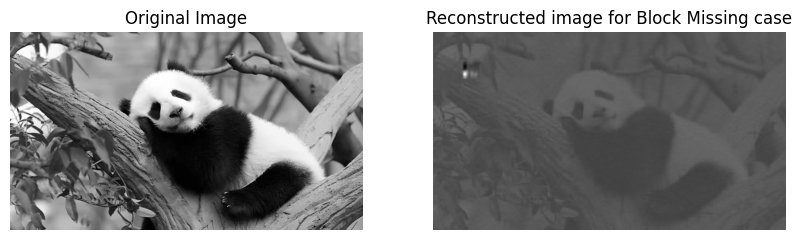

Block Missing: RMSE=0.087965, PSNR=21.11 dB


In [14]:
block_mask = torch.ones_like(X)
block_size = 30
start_row, start_col = 50, 50
block_mask[start_row:start_row+block_size, start_col:start_col+block_size] = 0
X_block_missing = X * block_mask

# Plot missing region
plt.figure(figsize=(5,5))
plt.imshow(X_block_missing.cpu(), cmap='gray')
plt.title("Block Missing 30x30")
plt.axis('off')
plt.show()

# Reconstruction
r = 60
X_block_rec = low_rank_reconstruction(X, block_mask, rank=r, lr=0.01, num_iters=10000)

# Plot original vs reconstructed
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(X.cpu(), cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(X_block_rec[0].cpu(), cmap='gray')
plt.title("Reconstructed image for Block Missing case")
plt.axis('off')
plt.show()

# Compute metrics
rmse_block, psnr_block = compute_metrics(X, X_block_rec[0])

print(f"Block Missing: RMSE={rmse_block:.6f}, PSNR={psnr_block:.2f} dB")

**case(ii)**: Reconstructing the image for a random subset of 900 (30X30) pixels is missing from the image.

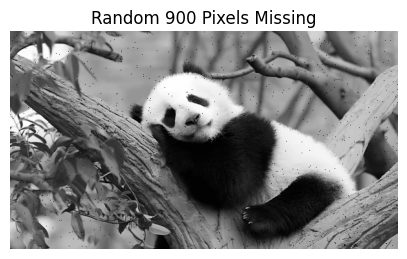

--- Starting Gradient Descent ---
GD Iteration     0, Loss=11948886.000000
GD Iteration   500, Loss=7238.087891
GD Iteration  1000, Loss=3719.273193
GD Iteration  1500, Loss=2757.185303
GD Iteration  2000, Loss=2324.012207
GD Iteration  2500, Loss=2053.346680
GD Iteration  3000, Loss=1866.960938
GD Iteration  3500, Loss=1725.824829
GD Iteration  4000, Loss=1595.480469
GD Iteration  4500, Loss=1460.905029
GD Iteration  5000, Loss=1330.957642
GD Iteration  5500, Loss=1214.016602
GD Iteration  6000, Loss=1107.332153
GD Iteration  6500, Loss=1009.527039
GD Iteration  7000, Loss=919.933411
GD Iteration  7500, Loss=839.431580
GD Iteration  8000, Loss=766.312866
GD Iteration  8500, Loss=703.287537
GD Iteration  9000, Loss=647.037354
GD Iteration  9500, Loss=603.849609
GD Iteration  9999, Loss=568.170532
--- Gradient Descent Finished ---



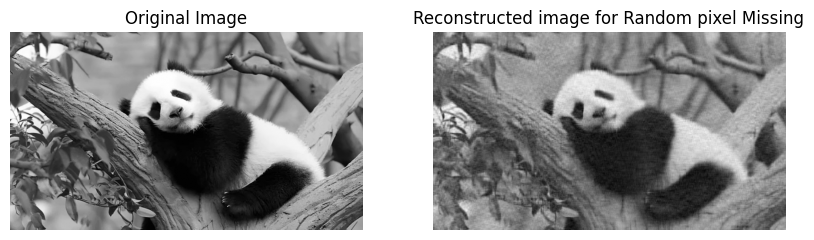

Random Missing: RMSE=0.053240, PSNR=25.48 dB


In [15]:
random_mask = torch.ones_like(X)
num_missing = 900
indices = torch.randperm(X.numel())[:num_missing]
random_mask.view(-1)[indices] = 0
X_random_missing = X * random_mask

# Plot missing region
plt.figure(figsize=(5,5))
plt.imshow(X_random_missing.cpu(), cmap='gray')
plt.title("Random 900 Pixels Missing")
plt.axis('off')
plt.show()

# Reconstruction
X_random_rec = low_rank_reconstruction(X, random_mask, rank=r, lr=0.01, num_iters=10000)

# Plot original vs reconstructed
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(X.cpu(), cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(X_random_rec[0].cpu(), cmap='gray')
plt.title("Reconstructed image for Random pixel Missing")
plt.axis('off')
plt.show()

# Compute metrics
rmse_random, psnr_random = compute_metrics(X, X_random_rec[0])
print(f"Random Missing: RMSE={rmse_random:.6f}, PSNR={psnr_random:.2f} dB")

Now as the factorization is done for Black and white which has 1 channel , we can extend the same algorithm to colored image , In the color image case, the input has three channels (R, G, B). Since our low-rank reconstruction method works on 2D matrices, we apply it independently to each channel. That means we treat the red, green, and blue layers as separate grayscale images, reconstruct the missing regions in each one using matrix factorization with gradient descent, and then stack the channels back together to form the final RGB image.

Loading the Image

In [16]:
def normalize_image(image_tensor):
    return image_tensor.float() / 255.0

color_img = torchvision.io.read_image(r'C:\Users\Parth Dembla\Downloads\Machine Learning\ES---335-ML-Assignment-2\Task 4\panda.jpg') 
color_img = normalize_image(color_img).to(device)

print("Image shape:", color_img.shape)  

Image shape: torch.Size([3, 337, 600])


**case(i)**: Reconstructing the image for a rectangular block of 30X30 is assumed missing from the image.

--- Starting Gradient Descent ---
GD Iteration     0, Loss=16007264.000000
GD Iteration   500, Loss=7273.147949
GD Iteration  1000, Loss=3607.780762
GD Iteration  1500, Loss=2775.235107
GD Iteration  2000, Loss=2372.565918
GD Iteration  2500, Loss=2077.944580
GD Iteration  3000, Loss=1845.156128
GD Iteration  3500, Loss=1650.289917
GD Iteration  4000, Loss=1479.783813
GD Iteration  4500, Loss=1325.948608
GD Iteration  5000, Loss=1190.871216
GD Iteration  5500, Loss=1071.062500
GD Iteration  6000, Loss=961.978333
GD Iteration  6500, Loss=863.106445
GD Iteration  7000, Loss=777.243469
GD Iteration  7500, Loss=700.956299
GD Iteration  8000, Loss=633.853638
GD Iteration  8500, Loss=580.341187
GD Iteration  9000, Loss=530.610229
GD Iteration  9500, Loss=491.566376
GD Iteration  9999, Loss=460.374420
--- Gradient Descent Finished ---

--- Starting Gradient Descent ---
GD Iteration     0, Loss=16214951.000000
GD Iteration   500, Loss=5933.588867
GD Iteration  1000, Loss=3655.141113
GD Iterati

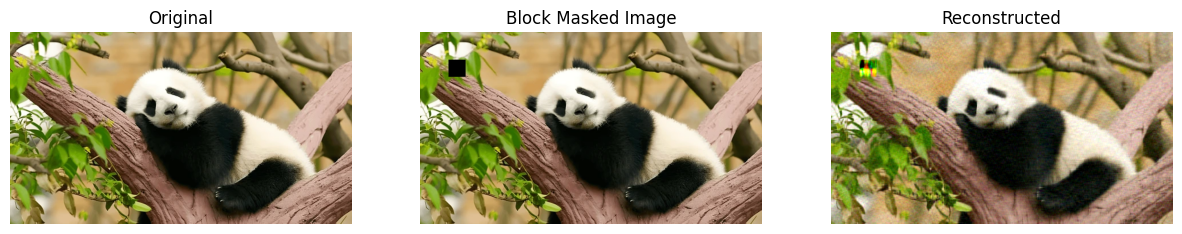

Block Missing: RMSE=0.065023, PSNR=23.74 dB


In [21]:
C, H, W = color_img.shape
block_mask = torch.ones((H, W), device=device)
block_size = 30
start_row, start_col = 50, 50
block_mask[start_row:start_row+block_size, start_col:start_col+block_size] = 0

rank = 80
color_block_missing = color_img * block_mask.unsqueeze(0)  # masked image
color_rec_block = []
for c in range(C):
    X = color_img[c]
    rec = low_rank_reconstruction(X, block_mask, rank=rank, lr=0.01, num_iters=10000)
    rec=rec[0]
    color_rec_block.append(rec)
    
color_rec_block = torch.stack(color_rec_block, dim=0)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(color_img.permute(1,2,0).cpu())
plt.title("Original")
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(color_block_missing.permute(1,2,0).cpu())
plt.title("Block Masked Image")
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(color_rec_block.permute(1,2,0).cpu().clamp(0,1))
plt.title("Reconstructed")
plt.axis('off')
plt.show()


rmse_block, psnr_block = compute_metrics(color_img, color_rec_block)
print(f"Block Missing: RMSE={rmse_block:.6f}, PSNR={psnr_block:.2f} dB")

**case(ii)**: Reconstructing the image for a random subset of 900 (30X30) pixels is missing from the image.

--- Starting Gradient Descent ---
GD Iteration     0, Loss=10102156.000000
GD Iteration   500, Loss=8268.225586
GD Iteration  1000, Loss=4110.061523
GD Iteration  1500, Loss=3220.492188
GD Iteration  2000, Loss=2818.506592
GD Iteration  2500, Loss=2620.409424
GD Iteration  3000, Loss=2394.877686
GD Iteration  3500, Loss=2132.543945
GD Iteration  4000, Loss=1901.900391
GD Iteration  4500, Loss=1709.372559
GD Iteration  5000, Loss=1544.875977
GD Iteration  5500, Loss=1402.872192
GD Iteration  6000, Loss=1274.269531
GD Iteration  6500, Loss=1152.938721
GD Iteration  7000, Loss=1039.604370
GD Iteration  7500, Loss=942.406372
GD Iteration  8000, Loss=860.332214
GD Iteration  8500, Loss=801.094849
GD Iteration  9000, Loss=740.417969
GD Iteration  9500, Loss=696.577942
GD Iteration  9999, Loss=659.372803
--- Gradient Descent Finished ---

--- Starting Gradient Descent ---
GD Iteration     0, Loss=10060149.000000
GD Iteration   500, Loss=6480.552734
GD Iteration  1000, Loss=3842.770996
GD Iter

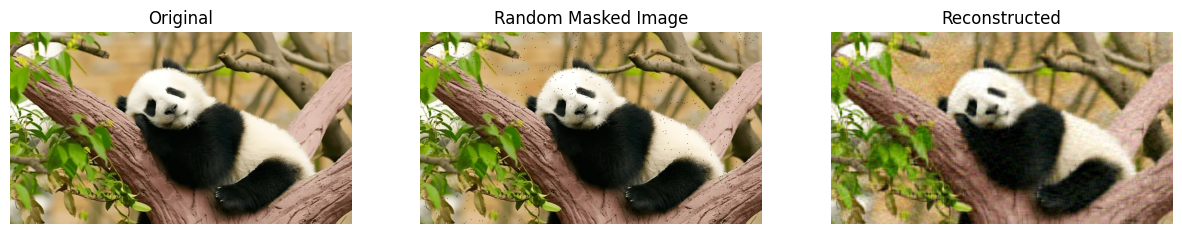

Random Missing: RMSE=0.056425, PSNR=24.97 dB


In [22]:
random_mask = torch.ones((H, W), device=device)
num_missing = 900
indices = torch.randperm(H*W, device=device)[:num_missing]
random_mask.view(-1)[indices] = 0
rank = 50
color_random_missing = color_img * random_mask.unsqueeze(0)  # masked image
color_rec_random = []
for c in range(C):
    X = color_img[c]
    rec = low_rank_reconstruction(X, random_mask, rank=rank, lr=0.01, num_iters=10000)
    rec = rec[0]
    color_rec_random.append(rec)
color_rec_random = torch.stack(color_rec_random, dim=0)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(color_img.permute(1,2,0).cpu())
plt.title("Original")
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(color_random_missing.permute(1,2,0).cpu())
plt.title("Random Masked Image")
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(color_rec_random.permute(1,2,0).cpu().clamp(0,1))
plt.title("Reconstructed")
plt.axis('off')
plt.show()

rmse_random, psnr_random = compute_metrics(color_img, color_rec_random)
print(f"Random Missing: RMSE={rmse_random:.6f}, PSNR={psnr_random:.2f} dB")


In low-rank matrix reconstruction, the rank 
r determines the expressive capacity of the factorization 
𝑋≈𝑊⋅𝐻
X≈W⋅H. A smaller rank enforces a simpler model, which can capture only the most dominant patterns in the image but fails to recover fine details, especially in large missing regions such as a 30×30 block. This often results in blurry or inaccurate reconstructions. Increasing the rank allows the model to represent more complex structures and textures, improving the reconstruction quality of missing pixels. However, a very high rank can lead to overfitting and increased computational cost. In practice, the rank is chosen as a trade-off: moderate values are sufficient for randomly missing pixels, while larger ranks are beneficial for reconstructing contiguous missing blocks where local information is unavailable. Adjusting the rank alongside the number of iterations and learning rate allows the gradient descent optimization to better approximate the high-resolution image.

## **Objective 2**  
Reconstruct the same images (Case 1 and 2) using **Alternating Least Squares (ALS)** instead of Gradient Descent.  

Tasks:  
- Write your own ALS function using [`torch.linalg.lstsq`](https://pytorch.org/docs/stable/generated/torch.linalg.lstsq.html).  
- Compare reconstructed results and metrics with the Gradient Descent approach.  


Loading the Image

In [23]:
def normalize_image(image_tensor):
    return image_tensor.float() / 255.0

color_img = torchvision.io.read_image(r'C:\Users\Parth Dembla\Downloads\Machine Learning\ES---335-ML-Assignment-2\Task 4\panda.jpg') 
color_img = normalize_image(color_img).to(device)

print("Image shape:", color_img.shape)  

Image shape: torch.Size([3, 337, 600])


Defining the Low rank Reconstruction Fuction using ALS Method

In [24]:
def low_rank_reconstruction_als(X, mask, rank, num_iters):
    """
    X     : [H,W] grayscale image (or one channel of colored image)
    mask  : [H,W] binary tensor: 1 for known pixels, 0 for missing
    rank  : rank for low-rank factorization
    num_iters : number of ALS iterations
    """
    m, n = X.shape
    device = X.device
    
    W = torch.randn(m, rank, device=device)
    H = torch.randn(rank, n, device=device)
    
    mask = mask.to(dtype=X.dtype)
    losses = []
    
    print("--- Starting Alternating Least Squares ---")
    for it in range(num_iters):
        # Update W,Fix H
        for i in range(m):
            known_idx = mask[i, :] == 1
            if known_idx.sum() == 0: continue
            H_sub = H[:, known_idx]
            X_sub = X[i, known_idx]
            w_i, _ = torch.linalg.lstsq(H_sub.T, X_sub.T)[:2]
            W[i, :] = w_i.T
            
        # Update H, Fix W
        for j in range(n):
            known_idx = mask[:, j] == 1
            if known_idx.sum() == 0: continue
            W_sub = W[known_idx, :]
            X_sub = X[known_idx, j]
            h_j, _ = torch.linalg.lstsq(W_sub, X_sub)[:2]
            H[:, j] = h_j.squeeze()

        #  printing the loss after each full iteration
        X_hat = torch.mm(W, H)
        loss = ((X_hat - X) * mask).pow(2).sum()
        losses.append(loss.item())

        print(f"ALS Iteration {it:2d}, Loss={loss.item():.6f}")
        
    print("--- ALS Finished ---\n")
    return torch.mm(W, H), losses

**case(i)**: Reconstructing the image for a rectangular block of 30X30 is assumed missing from the image.

--- Starting Alternating Least Squares ---


C:\Users\Parth Dembla\AppData\Local\Temp\ipykernel_45364\4057518046.py:25: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4424.)
  w_i, _ = torch.linalg.lstsq(H_sub.T, X_sub.T)[:2]


ALS Iteration  0, Loss=590.062866
ALS Iteration  1, Loss=246.170013
ALS Iteration  2, Loss=223.044220
ALS Iteration  3, Loss=216.407043
ALS Iteration  4, Loss=213.688263
ALS Iteration  5, Loss=212.279816
ALS Iteration  6, Loss=211.414612
ALS Iteration  7, Loss=210.813049
ALS Iteration  8, Loss=210.357620
ALS Iteration  9, Loss=209.993362
ALS Iteration 10, Loss=209.691544
ALS Iteration 11, Loss=209.435532
ALS Iteration 12, Loss=209.214859
ALS Iteration 13, Loss=209.022583
ALS Iteration 14, Loss=208.853821
ALS Iteration 15, Loss=208.704865
ALS Iteration 16, Loss=208.572769
ALS Iteration 17, Loss=208.455048
ALS Iteration 18, Loss=208.349426
ALS Iteration 19, Loss=208.254044
ALS Iteration 20, Loss=208.167114
ALS Iteration 21, Loss=208.087280
ALS Iteration 22, Loss=208.013367
ALS Iteration 23, Loss=207.944489
ALS Iteration 24, Loss=207.879990
ALS Iteration 25, Loss=207.819412
ALS Iteration 26, Loss=207.762451
ALS Iteration 27, Loss=207.708954
ALS Iteration 28, Loss=207.658798
ALS Iteration 

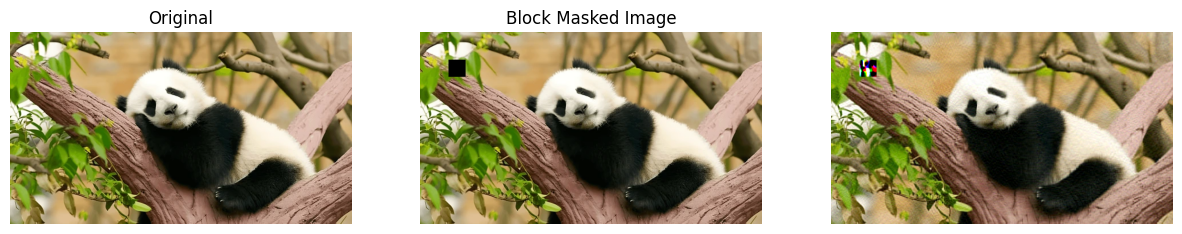

In [25]:
block_mask = torch.ones((H, W), device=device)
block_size = 30
block_mask[50:50+block_size, 50:50+block_size] = 0

color_block_missing = color_img * block_mask.unsqueeze(0)

# ALS reconstruction for each channel
rank = 80
color_rec_block_als = []
for c in range(C):
    X = color_img[c]
    rec = low_rank_reconstruction_als(X, block_mask, rank=rank, num_iters=30)
    rec=rec[0]
    color_rec_block_als.append(rec)
color_rec_block_als = torch.stack(color_rec_block_als, dim=0)

rmse_block_als, psnr_block_als = compute_metrics(color_img, color_rec_block_als)
print(f"Block Missing: RMSE={rmse_block_als:.6f}, PSNR={psnr_block_als:.2f} dB")


plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(color_img.permute(1,2,0).cpu())
plt.title("Original")
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(color_block_missing.permute(1,2,0).cpu())
plt.title("Block Masked Image")
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(color_rec_block_als.permute(1,2,0).cpu().clamp(0,1))
plt.axis('off')
plt.show()

**case(ii)**: Reconstructing the image for a random subset of 900 (30X30) pixels is missing from the image.

--- Starting Alternating Least Squares ---
ALS Iteration  0, Loss=1586.010620
ALS Iteration  1, Loss=523.607361
ALS Iteration  2, Loss=479.745605
ALS Iteration  3, Loss=467.172485
ALS Iteration  4, Loss=461.280945
ALS Iteration  5, Loss=457.573914
ALS Iteration  6, Loss=454.977417
ALS Iteration  7, Loss=453.198914
ALS Iteration  8, Loss=452.038147
ALS Iteration  9, Loss=451.298981
ALS Iteration 10, Loss=450.827637
ALS Iteration 11, Loss=450.521545
ALS Iteration 12, Loss=450.317261
ALS Iteration 13, Loss=450.176361
ALS Iteration 14, Loss=450.075623
ALS Iteration 15, Loss=450.000916
ALS Iteration 16, Loss=449.943451
ALS Iteration 17, Loss=449.897888
ALS Iteration 18, Loss=449.860657
ALS Iteration 19, Loss=449.829529
ALS Iteration 20, Loss=449.803070
ALS Iteration 21, Loss=449.780090
ALS Iteration 22, Loss=449.759979
ALS Iteration 23, Loss=449.742157
ALS Iteration 24, Loss=449.726379
ALS Iteration 25, Loss=449.712189
ALS Iteration 26, Loss=449.699463
ALS Iteration 27, Loss=449.687927
ALS 

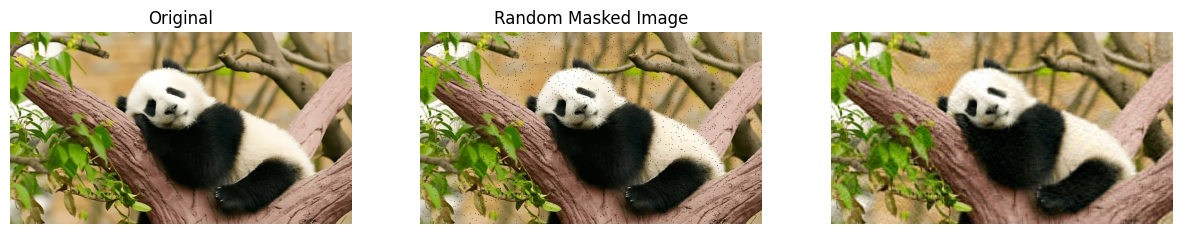

In [26]:
random_mask = torch.ones((H, W), device=device)
num_missing = 2000
indices = torch.randperm(H*W, device=device)[:num_missing]
random_mask.view(-1)[indices] = 0
rank = 50
color_random_missing = color_img * random_mask.unsqueeze(0)

# ALS reconstruction for each channel
color_rec_random_als = []
for c in range(C):
    X = color_img[c]
    rec = low_rank_reconstruction_als(X, random_mask, rank=rank, num_iters=30)
    rec = rec[0]
    color_rec_random_als.append(rec)
color_rec_random_als = torch.stack(color_rec_random_als, dim=0)

rmse_random_als, psnr_random_als = compute_metrics(color_img, color_rec_random_als)

print(f"Random Missing: RMSE={rmse_random_als:.6f}, PSNR={psnr_random_als:.2f} dB")


plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(color_img.permute(1,2,0).cpu())
plt.title("Original")
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(color_random_missing.permute(1,2,0).cpu())
plt.title("Random Masked Image")
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(color_rec_random_als.permute(1,2,0).cpu().clamp(0,1))

plt.axis('off')
plt.show()


**Comparing the ALS and Gradient Descent Results**

Let's look at the convergence

--- Starting Gradient Descent ---
GD Iteration     0, Loss=9782083.000000
GD Iteration   500, Loss=8128.140625
GD Iteration  1000, Loss=4297.134277
GD Iteration  1500, Loss=3389.049805
GD Iteration  2000, Loss=2868.656982
GD Iteration  2500, Loss=2482.040283
GD Iteration  3000, Loss=2154.308350
GD Iteration  3500, Loss=1918.974121
GD Iteration  4000, Loss=1736.533813
GD Iteration  4500, Loss=1585.412720
GD Iteration  5000, Loss=1451.283936
GD Iteration  5500, Loss=1325.992554
GD Iteration  6000, Loss=1209.009766
GD Iteration  6500, Loss=1102.263184
GD Iteration  7000, Loss=1007.045044
GD Iteration  7500, Loss=924.036926
GD Iteration  8000, Loss=852.615234
GD Iteration  8500, Loss=786.560547
GD Iteration  9000, Loss=732.317017
GD Iteration  9500, Loss=685.745605
GD Iteration  9999, Loss=648.975159
--- Gradient Descent Finished ---

--- Starting Alternating Least Squares ---
ALS Iteration  0, Loss=1580.694458
ALS Iteration  1, Loss=528.822693
ALS Iteration  2, Loss=477.636658
ALS Iterati

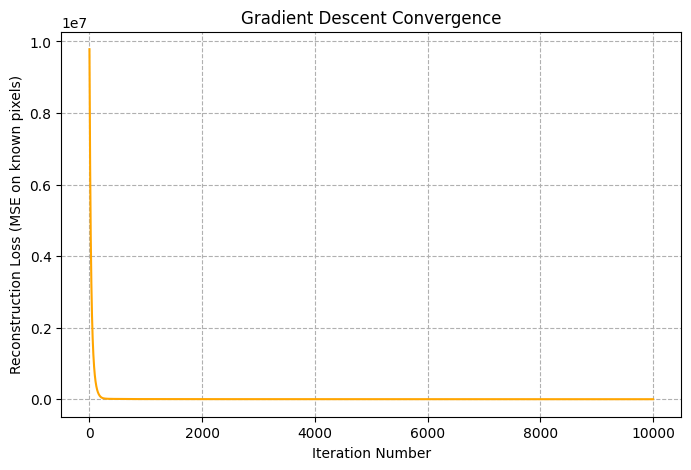

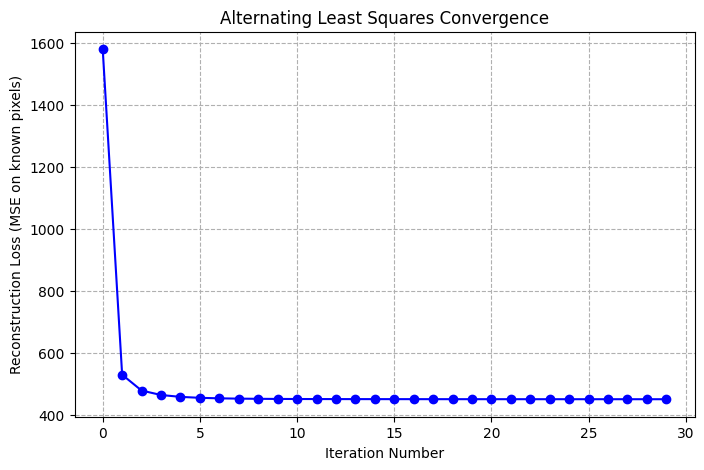

In [31]:
# using the first channel of the image as an example
X_channel_0 = color_img[0]
rank = 50 

# Run Gradient Descent and get loss history (using 2000 iterations for the example)
_, gd_losses = low_rank_reconstruction(
    X_channel_0, random_mask, rank=rank, lr=0.01, num_iters=10000
)

# Run ALS and get loss history
_, als_losses = low_rank_reconstruction_als(
    X_channel_0, random_mask, rank=rank, num_iters=30
)

# Gradient Descent plot 
plt.figure(figsize=(8, 5))
plt.plot(gd_losses, color='orange')
plt.title('Gradient Descent Convergence')
plt.xlabel('Iteration Number')
plt.ylabel('Reconstruction Loss (MSE on known pixels)')
plt.grid(True, which="both", ls="--")
plt.show()

# ALS plot
plt.figure(figsize=(8, 5))
plt.plot(als_losses, color='blue', marker='o')
plt.title('Alternating Least Squares Convergence')
plt.xlabel('Iteration Number')
plt.ylabel('Reconstruction Loss (MSE on known pixels)')
plt.grid(True, which="both", ls="--")
plt.show()


Now comparing RMSE and PSNR

In [32]:
import pandas as pd

results_data = []

# Metrics for Gradient Descent (Block Missing)
rmse_block_gd, psnr_block_gd = compute_metrics(color_img, color_rec_block)
results_data.append({
    'Case': '30x30 Missing Block',
    'Method': 'Gradient Descent',
    'Rank': 80,
    'Iterations': 10000,
    'RMSE': f"{rmse_block_gd:.6f}",
    'PSNR (dB)': f"{psnr_block_gd:.2f}"
})

# Metrics for ALS (Block Missing)
rmse_block_als, psnr_block_als = compute_metrics(color_img, color_rec_block_als)
results_data.append({
    'Case': '30x30 Missing Block',
    'Method': 'ALS',
    'Rank': 80,
    'Iterations': 30,
    'RMSE': f"{rmse_block_als:.6f}",
    'PSNR (dB)': f"{psnr_block_als:.2f}"
})

# Metrics for Gradient Descent (Random Missing)
rmse_random_gd, psnr_random_gd = compute_metrics(color_img, color_rec_random)
results_data.append({
    'Case': 'Random 900 Missing Pixels',
    'Method': 'Gradient Descent',
    'Rank': 50,
    'Iterations': 10000,
    'RMSE': f"{rmse_random_gd:.6f}",
    'PSNR (dB)': f"{psnr_random_gd:.2f}"
})

# Metrics for ALS (Random Missing)
rmse_random_als, psnr_random_als = compute_metrics(color_img, color_rec_random_als)
results_data.append({
    'Case': 'Random 900 Missing Pixels',
    'Method': 'ALS',
    'Rank': 50,
    'Iterations': 30,
    'RMSE': f"{rmse_random_als:.6f}",
    'PSNR (dB)': f"{psnr_random_als:.2f}"
})


results_df = pd.DataFrame(results_data)


print("Comparison of Final Metrics")
print(results_df.to_string())

Comparison of Final Metrics
                        Case            Method  Rank  Iterations      RMSE PSNR (dB)
0        30x30 Missing Block  Gradient Descent    80       10000  0.065023     23.74
1        30x30 Missing Block               ALS    80          30  0.109234     19.23
2  Random 900 Missing Pixels  Gradient Descent    50       10000  0.056425     24.97
3  Random 900 Missing Pixels               ALS    50          30  0.046426     26.66
